## Development Environment for Model Building

This notebook serves as our development environment and is divided into different phases:

**Phase 1 — Data Understanding & Cleaning**
1. Load dataset, confirm shape/columns
2. Check missing values, decide handling per column
3. Explore class balance (`queue` counts, `priority` counts, `language` split)
4. Combine `subject` + `body` into a single `text` field
5. Basic text stats (length distribution, duplicates check)

**Phase 2 — Sentiment Label Generation (since it doesn't exist in the data)**

6. Pick a local pretrained sentiment model (e.g. multilingual BERT-based)
7. Run it over the full dataset to generate sentiment labels
8. Pull a random sample (~250-300 rows), manually label as a team
9. Compare model labels vs human labels, compute agreement (Cohen's kappa)
10. Sanity-check generated sentiment against `priority` (Critical should skew more negative)
11. Decide: keep as-is, or refine the rubric/model if agreement is weak

**Phase 3 — Train/Test Prep**

12. Stratified train/validation/test split (by `queue`, ideally checking `sentiment` balance too)
13. Decide feature representation: TF-IDF vs multilingual sentence embeddings
14. Turn `text` into features on train/val/test consistently (fit on train only)

**Phase 4 — Modeling**

15. Train baseline **intent model** (text → `queue`), evaluate (F1 per class, confusion matrix)
16. Train baseline **sentiment model** (text → sentiment), evaluate similarly
17. Check performance by language (English vs German) — catch any imbalance in accuracy
18. (Stretch) Train a small fine-tuned transformer, compare vs classical baseline
19. Pick final models, save them (`joblib`/model folder)

**Phase 5 — Turn Notebook Into Code**

20. Refactor cleaning + feature prep into reusable functions/scripts
21. Wrap into a single `classify_and_route(text, language)` function
22. Save trained models to disk in a form the app can load


In [1]:
!pip install sentence-transformers --q

In [2]:
!pip install xgboost --q

In [3]:
!pip install transformers torch --q

In [4]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import os

from datasets import load_dataset
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, cohen_kappa_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

from sentence_transformers import SentenceTransformer
from transformers import pipeline

In [5]:
#loading datasets
ds = load_dataset("Tobi-Bueck/customer-support-tickets")
df = ds["train"].to_pandas()

README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [6]:
#size of dataset
df.shape

(61765, 16)

In [7]:
#dataset preview
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [8]:
#selecting columns of interest and create a new dataframe
df2 = df[['subject', 'body', 'queue', 'priority', 'language']]
df2.head()

,subject,body,queue,priority,language
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high,de
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,en
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,en
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,en
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,en


### Data Exploration and Cleaning

In [9]:
#checking data types
df2.dtypes

subject     object
body        object
queue       object
priority    object
language    object
dtype: object

We have all the datasets in the right data types

In [10]:
#checking for duplicates
df2.duplicated().sum()

np.int64(8306)

In [11]:
#to see the rows that are being duplicated
df2[df2.duplicated(keep=False)].sort_values('body')

,subject,body,queue,priority,language
50310,Modify Billing Arrangement,Assistance Required,Billing and Payments,high,en
15127,Modify Billing Arrangement,Assistance Required,Billing and Payments,high,en
13193,Datenprobleme,Schwierigkeiten bei der Datenzugriffsermächti...,Product Support,medium,de
59235,Datenprobleme,Schwierigkeiten bei der Datenzugriffsermächti...,Product Support,medium,de
15154,None,"geehrte Kundenservice, könnten Sie mir zusätz...",Product Support,high,de
...,...,...,...,...,...
15983,Assistance with Downtime Problems,went through unforeseen downtime with various ...,Service Outages and Maintenance,medium,en
49460,Service Unterbrechung,wir erleben momentan signifikante Dienstunterb...,Service Outages and Maintenance,high,de
16934,Service Unterbrechung,wir erleben momentan signifikante Dienstunterb...,Service Outages and Maintenance,high,de
49471,None,"wirten Sie, um Integration von Zapier mit best...",Billing and Payments,medium,de


We would drop these duplicates first.

In [12]:
#dropping duplicates
df2 = df2.drop_duplicates()
df2.shape

(53459, 5)

In [13]:
#checking for missing values
df2.isnull().sum()

subject     4122
body           2
queue          0
priority       0
language       0
dtype: int64

Analysing the missing values and possible next steps:

- The data has about 4,000+ rows that are missing a subject. What approach would be best here to handle missing values? Since we'll be concatenating the message body to the subject, for cases where the subject is missing we can replace it with an empty string so that the concatenation still works.
- There are two instances where the body of the message is missing, we would need to drop those rows given that the body is a major part of what the model is expected to learn from.


In [14]:
#checking the rows where body is missing
df2[df2['body'].isnull()]

,subject,body,queue,priority,language
59452,Moodle integration broke unexpectedly due to a...,None,Product Support,medium,en
59724,Mehrmale Integrationsvorgänge gingen über Nach...,None,Product Support,medium,de


In [15]:
#handling missing values

#dropping rows where body is null
df2 = df2.dropna(subset=['body'])

#replacing missing subkect woyj an empty string
df2['subject'] = df2['subject'].fillna('')

df2.isnull().sum()

subject     0
body        0
queue       0
priority    0
language    0
dtype: int64

In [16]:
#the distribution of the different teams we'll be routing the messages to
df2['queue'].value_counts()

queue
Technical Support                         11779
Product Support                            7422
Customer Service                           6114
IT Support                                 4793
Billing and Payments                       4030
Returns and Exchanges                      2007
Service Outages and Maintenance            1569
Sales and Pre-Sales                        1256
Human Resources                             749
General Inquiry                             560
Pets & Animals/Pet Services                 386
News                                        383
IT & Technology/Security Operations         365
Autos & Vehicles/Sales                      364
Health/Medical Services                     362
Home & Garden/Home Improvement              361
Pets & Animals/Veterinary Care              356
Health/Mental Health                        347
Business & Industrial/Manufacturing         346
Online Communities/Forums                   343
Shopping/E-commerce               

We have 52 unique rows for teams. Given our use case of a SaaS company, we would filter the dataset to focus on the queues as seen below.

In [17]:
official_queues = [
    'Billing and Payments', 'Customer Service', 'General Inquiry',
    'Human Resources', 'IT Support', 'Product Support',
    'Returns and Exchanges', 'Sales and Pre-Sales',
    'Service Outages and Maintenance', 'Technical Support'
]

df2 = df2[df2['queue'].isin(official_queues)]
df2.shape

(40279, 5)

In [18]:
df2['queue'].value_counts()

queue
Technical Support                  11779
Product Support                     7422
Customer Service                    6114
IT Support                          4793
Billing and Payments                4030
Returns and Exchanges               2007
Service Outages and Maintenance     1569
Sales and Pre-Sales                 1256
Human Resources                      749
General Inquiry                      560
Name: count, dtype: int64

In [19]:
#distribution of the message priority
df2['priority'].value_counts()

priority
medium    16356
high      15708
low        8215
Name: count, dtype: int64

In [20]:
#distribution of langauges in the datasets
df2['language'].value_counts()

language
en    23747
de    16532
Name: count, dtype: int64

We have quite a number of german messages. There are two posisble approaches here:
- We translate every german ticket to english before it is used in training
- We retain the german language tickets as is and use multilingual embeddings

The most viable option is going with option 2. In option 1, the downside is that:

- It ads a translation model/step as a dependency
- Translation quality varies and can distort tone/sentiment (translation often flattens emotional nuance which is the signal our sentiment model needs).

In [21]:
#combining subject and body to one text field
df2['text'] = (df2['subject'] + ' ' + df2['body']).str.strip()

df2[['subject', 'body', 'text']].head()

,subject,body,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Question About Marketing Agency Software Compa...


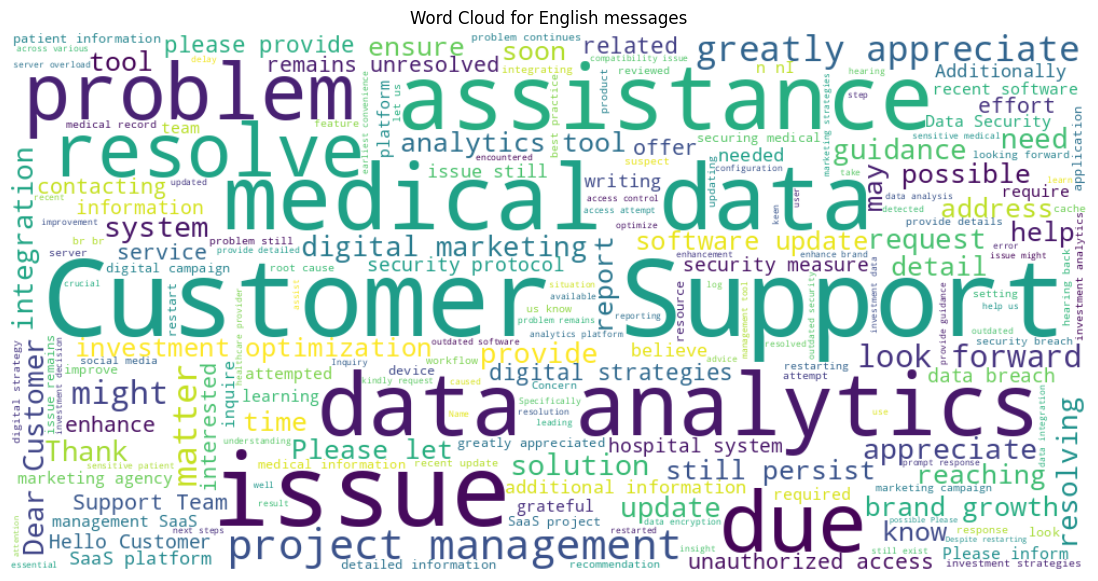

In [22]:
#buiding a word cloud to identify common words
en_text = ' '.join(df2[df2['language'] == 'en']['text'])

wc = WordCloud(width=1000, height=500, background_color='white').generate(en_text)

plt.figure(figsize=(15,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for English messages')
plt.show()

In [23]:
df2.head()

,subject,body,queue,priority,language,text
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Technical Support,high,de,Wesentlicher Sicherheitsvorfall Sehr geehrtes ...
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...",Technical Support,high,en,"Account Disruption Dear Customer Support Team,..."
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Returns and Exchanges,medium,en,Query About Smart Home System Integration Feat...
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",Billing and Payments,low,en,Inquiry Regarding Invoice Details Dear Custome...
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Sales and Pre-Sales,medium,en,Question About Marketing Agency Software Compa...


In [24]:
#train, validation and test splits
train_df, temp_df = train_test_split (df2, test_size=0.30, stratify=df2['queue'], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['queue'], random_state=42)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(28195, 6)
(6042, 6)
(6042, 6)


stratify is used to ensure that the proportion of queues across each split is roughly consistent.

In [25]:
train_df['queue'].value_counts(normalize=True) * 100

queue
Technical Support                  29.242774
Product Support                    18.428799
Customer Service                   15.179996
IT Support                         11.899273
Billing and Payments               10.005320
Returns and Exchanges               4.983153
Service Outages and Maintenance     3.894308
Sales and Pre-Sales                 3.117574
Human Resources                     1.858486
General Inquiry                     1.390317
Name: proportion, dtype: float64

In [26]:
val_df['queue'].value_counts(normalize=True) * 100

queue
Technical Support                  29.245283
Product Support                    18.421053
Customer Service                   15.177094
IT Support                         11.900033
Billing and Payments                9.996690
Returns and Exchanges               4.981794
Service Outages and Maintenance     3.905991
Sales and Pre-Sales                 3.111552
Human Resources                     1.870242
General Inquiry                     1.390268
Name: proportion, dtype: float64

In [27]:
test_df['queue'].value_counts(normalize=True) * 100

queue
Technical Support                  29.245283
Product Support                    18.421053
Customer Service                   15.177094
IT Support                         11.900033
Billing and Payments               10.013241
Returns and Exchanges               4.981794
Service Outages and Maintenance     3.889441
Sales and Pre-Sales                 3.128103
Human Resources                     1.853691
General Inquiry                     1.390268
Name: proportion, dtype: float64

### Training the Intent model

Before we proceed, we need to understand the following:

- Sentiment: answers "How does the customer feel" (Positive/Neutral/Negative). There is currently no label for this in the dataset and we would have to create it later on.

Intent and routing refer to the same underlying signal, used two ways:

- Intent = "what is this message about" → we predict this directly from the text, and the model's answer is the queue column (Technical Support, Billing and Payments, etc.)
- Routing = "where should it go" → once we know the predicted queue, routing is just: send it to that team.


Step 1: Feature representation

We are using a multilingual sentence embedding model to turn text into numeric features or representations

In [28]:
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Step 2: Generate embeddings for train/val/test

Unlike TF-IDF where you fit on your train data, senetence embedding models are already pretrained. This means that there is no fitting step and that we just encode each data split independetly.

In [29]:
X_train = embedder.encode(train_df['text'].tolist(), show_progress_bar=True, batch_size=64)
X_val = embedder.encode(val_df['text'].tolist(), show_progress_bar=True, batch_size=64)
X_test = embedder.encode(test_df['text'].tolist(), show_progress_bar=True, batch_size=64)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

Batches:   0%|          | 0/441 [00:00<?, ?it/s]

Batches:   0%|          | 0/95 [00:00<?, ?it/s]

Batches:   0%|          | 0/95 [00:00<?, ?it/s]

(28195, 384)
(6042, 384)
(6042, 384)


Step 3: Extract labels

In [26]:
y_train = train_df['queue']
y_val = val_df['queue']
y_test = test_df['queue']

Step 4: Training an untuned baseline classifier

In [27]:
baseline_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline_lr.fit(X_train, y_train)

y_val_pred_baseline = baseline_lr.predict(X_val)
print(classification_report(y_val, y_val_pred_baseline))

                                 precision    recall  f1-score   support

           Billing and Payments       0.67      0.68      0.67       604
               Customer Service       0.31      0.18      0.23       917
                General Inquiry       0.05      0.36      0.09        84
                Human Resources       0.09      0.41      0.15       113
                     IT Support       0.27      0.23      0.25       719
                Product Support       0.32      0.16      0.21      1113
          Returns and Exchanges       0.13      0.24      0.17       301
            Sales and Pre-Sales       0.13      0.43      0.19       188
Service Outages and Maintenance       0.28      0.70      0.40       236
              Technical Support       0.50      0.23      0.32      1767

                       accuracy                           0.28      6042
                      macro avg       0.27      0.36      0.27      6042
                   weighted avg       0.37      0

Step 5: Training classifier models

We are training 4 models:
- Logistic regression: that will be tuned
- RandomForest
- SVC
- XGB: requires interger labels unlike the rest

In [28]:
#label encoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.fit_transform(y_val)

In [30]:
#model search space for hyperparameter tuning
model_configs = {
    'Logistic Regression': {
        'estimator': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'param_dist': {'C': [0.01, 0.1, 1, 10, 100]},
        'uses_encoded_labels': False
    },
    'SVM': {
        'estimator': SVC(class_weight='balanced', random_state=42),
        'param_dist': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
        'uses_encoded_labels': False
    },
    'Random Forest': {
        'estimator': RandomForestClassifier(class_weight='balanced', random_state=42),
        'param_dist': {'n_estimators': [100, 200, 300], 'max_depth': [10,20,None]},
        'uses_encoded_labels': False
    },
    'XGBoost': {
        'estimator': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
        'param_dist': {'n_estimators': [100, 200], 'max_depth': [3,6,9], 'learning_rate': [0.01, 0.1, 0.3]},
        'uses_encoded_labels': True
    }
}

In [30]:
results = []
fitted_models = {}

for name, config in model_configs.items():
    print(f"\n Training {name}")

    y_tr = y_train_enc if config['uses_encoded_labels'] else y_train
    y_va = y_val_enc if config['uses_encoded_labels'] else y_val

    search = RandomizedSearchCV(
        config['estimator'],
        config['param_dist'],
        n_iter=5,
        cv=3,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train, y_tr)

    y_val_pred = search.predict(X_val)
    val_f1_macro = f1_score(y_va, y_val_pred, average='macro')
    val_f1_weighted = f1_score(y_va, y_val_pred, average='weighted')

    results.append({
        'model': name,
        'best_params': search.best_params_,
        'cv_f1_macro': search.best_score_,
        'val_f1_macro': val_f1_macro,
        'val_f1_weighted': val_f1_weighted
    })

    fitted_models[name] = search.best_estimator_
    print(f"{name} - val macro F1: {val_f1_macro:.4f}")



 Training Logistic Regression
Logistic Regression - val macro F1: 0.2742

 Training SVM


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


SVM - val macro F1: 0.6391

 Training Random Forest
Random Forest - val macro F1: 0.4780

 Training XGBoost
XGBoost - val macro F1: 0.4010


In [31]:
results_df = pd.DataFrame(results).sort_values('val_f1_macro', ascending=False)
results_df

,model,best_params,cv_f1_macro,val_f1_macro,val_f1_weighted
1,SVM,"{'kernel': 'rbf', 'C': 10}",0.571598,0.639149,0.642496
2,Random Forest,"{'n_estimators': 300, 'max_depth': 20}",0.412414,0.477980,0.545736
3,XGBoost,"{'n_estimators': 100, 'max_depth': 6, 'learnin...",0.374619,0.400976,0.471091
0,Logistic Regression,{'C': 10},0.263478,0.274228,0.302188


The table above shows us the performance of difefrent models on the dataset.

First, we can see that even with more tuning, the Logistic Regression model is very similar to the baseline model we trained earlier. This shows us that linear models are too simple and struggle becasue boundaries betwen intent classes in embedding spaces are not so easily seperable.

The best model based on f1_Score is the SVM where the f1 score is comfortably ahead of random forest and xgboost. Here, in SVM, with kernels like RBF it can draw curved decision boundaries which fits the data better.

In [32]:
y_val_pred_svm = fitted_models['SVM'].predict(X_val)
print(classification_report(y_val, y_val_pred_svm))

                                 precision    recall  f1-score   support

           Billing and Payments       0.82      0.81      0.81       604
               Customer Service       0.55      0.65      0.59       917
                General Inquiry       0.64      0.51      0.57        84
                Human Resources       0.71      0.60      0.65       113
                     IT Support       0.60      0.60      0.60       719
                Product Support       0.60      0.58      0.59      1113
          Returns and Exchanges       0.56      0.60      0.58       301
            Sales and Pre-Sales       0.62      0.62      0.62       188
Service Outages and Maintenance       0.68      0.73      0.70       236
              Technical Support       0.69      0.64      0.67      1767

                       accuracy                           0.64      6042
                      macro avg       0.65      0.64      0.64      6042
                   weighted avg       0.65      0

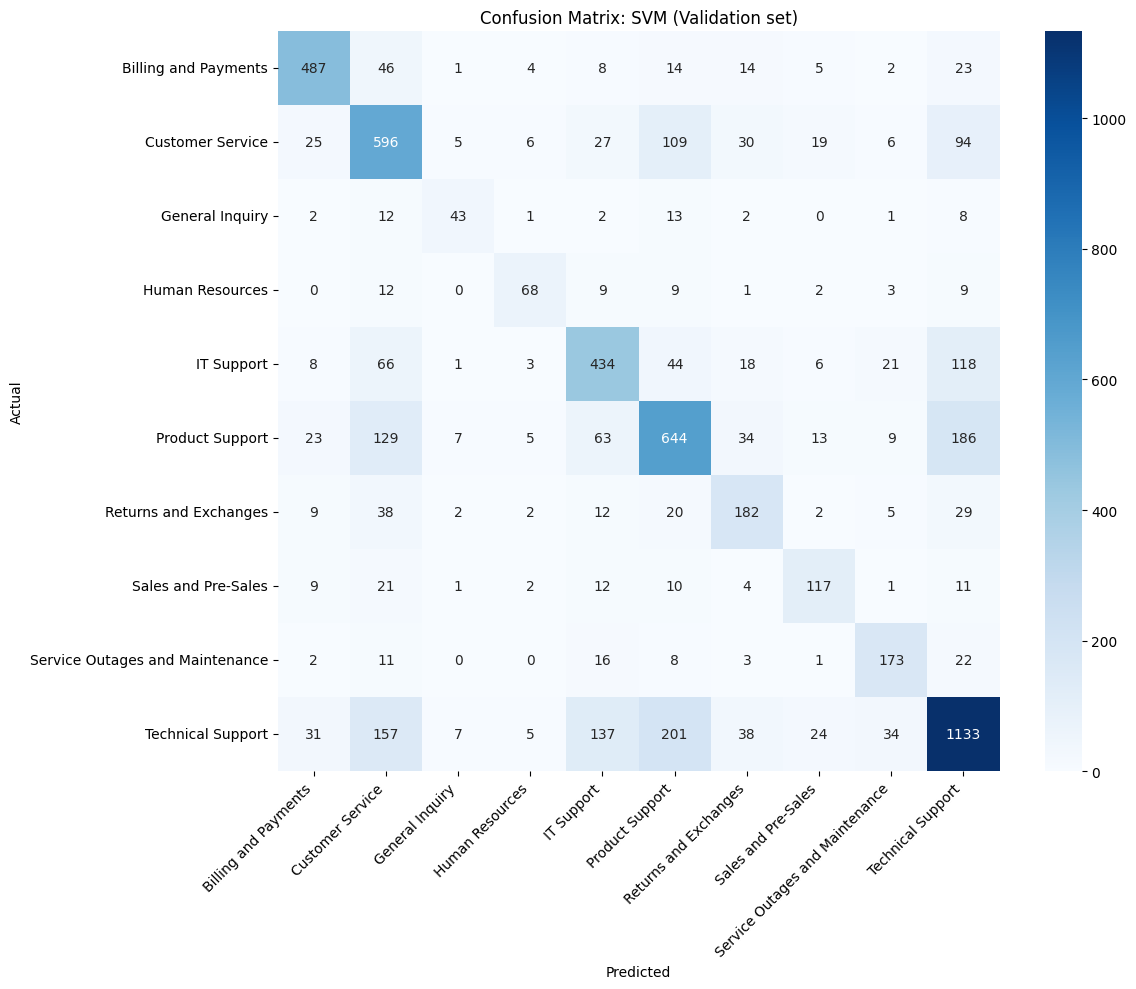

In [33]:
#creating a confusion matrix

labels = sorted(y_val.unique())
cm = confusion_matrix(y_val, y_val_pred_svm, labels=labels)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: SVM (Validation set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Looking closely at this chart, we can see some dominant confusion cluster: Technical Support ↔ Product Support ↔ Customer Service ↔ IT Support.

- Technical Support gets confused as Product Support, Customer Service, and IT Support.
- Product Support gets confused as Technical Support and Customer Service.
- IT Support gets confused as Technical Support

Thinking about these clusters in a business sense liek when a customer drops a message or sends an email saying: 

"My dashboard keeps crashing"

This message is quite ambiguous and can land in eitehr Technical support, IT support or product support depending on how NorthStack draws lines between thsoe roles.

In [34]:
#saving the svm model
os.makedirs('models', exist_ok=True)
joblib.dump(fitted_models['SVM'], 'models/intent_classifier_svm.joblib')

print('Model saved')

Model saved


### Building the Sentiment Model

In [35]:
#defining multilingual sentiment model
sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [36]:
#running a quick test to see the output
sentiment_model("This is completely unacceptable, I want a refund immediately")

[{'label': '1 star', 'score': 0.9060671329498291}]

In [37]:
sentiment_model("Vielen Dank für die schnelle Hilfe!")

[{'label': '5 stars', 'score': 0.6913811564445496}]

The result of using the sentiment model includes a label: 1-5 starts which tells us where the sentiment seats and a score of how the probability that the text belongs to that rating.

In [40]:
#mapping stars to sentiment
def map_stars_to_sentiment(label):
    star = int(label[0])
    if star <= 2:
        return "Negative"
    elif star == 3:
        return "Neutral"
    else:
        return "Positive"

In [41]:
#applying it across the dataset

#truncating long messages since the model has a token limit
texts = df2["text"].str.slice(0,512).tolist()

results = sentiment_model(texts, batch_size=32, truncation=True)

df2['sentiment_raw'] = [r['label'] for r in results]
df2['sentiment'] = df2['sentiment_raw'].apply(map_stars_to_sentiment)

In [42]:
#checking sentiment distribution
df2['sentiment'].value_counts()

sentiment
Negative    19078
Positive    15791
Neutral      5410
Name: count, dtype: int64

In [44]:
#bilingual manual validation sample
en_sample = df2[df2['language'] == 'en'].sample(n=40, random_state=42)
de_sample = df2[df2['language'] == 'de'].sample(n=40, random_state=42)

validation_sample = pd.concat([en_sample, de_sample])[['text', 'language', 'priority', 'sentiment']].copy()
validation_sample['language'].value_counts()

language
en    40
de    40
Name: count, dtype: int64

In [45]:
validation_sample.head()

,text,language,priority,sentiment
49478,Incident Report: Marketing Agency Digital Stra...,en,high,Negative
10449,Trouble with Twitch Studio Beta Integration Ex...,en,low,Negative
28260,Update Integration Settings for Compatibility ...,en,medium,Neutral
26293,Immediate Security Assistance Required A secur...,en,medium,Neutral
24927,Support for Integrating Microsoft SQL Server 2...,en,low,Positive


In [46]:
validation_for_labeling = validation_sample.copy()
validation_for_labeling['human_label'] = ''
validation_for_labeling.to_csv('sentiment_validation_sample.csv', index=False)

In [48]:
#saving relevant files
df2.to_csv('data_queue_sentiment.csv', index=False)
test_df.to_csv('test.csv', index=False)

In [59]:
train_df

,subject,body,queue,priority,language,text
54263,Support Inquiry for Billing Discrepancies,Encountering unexpected billing inconsistencie...,Billing and Payments,high,en,Support Inquiry for Billing Discrepancies Enco...
16484,Problem with Access to Project Management Tool,We are encountering intermittent outages with ...,Returns and Exchanges,high,en,Problem with Access to Project Management Tool...
21502,Support for Repeated Crashes in ClickUp-Integr...,Experiencing recurring crashes while using Cli...,Customer Service,low,de,Support for Repeated Crashes in ClickUp-Integr...
55150,Trouble with Data Analytics Dashboard,"Hello Customer Support, I am contacting you to...",Product Support,high,en,Trouble with Data Analytics Dashboard Hello Cu...
176,Client Reporting Dashboard Refresh Issue,"Dear Customer Support Team,\n\nI hope this mes...",Technical Support,high,en,Client Reporting Dashboard Refresh Issue Dear ...
...,...,...,...,...,...,...
22813,,"customer support, expressing interest in impro...",Product Support,medium,en,"customer support, expressing interest in impro..."
49660,Microsoft Support Inquiry,Is there any information on the compatibility ...,Product Support,medium,en,Microsoft Support Inquiry Is there any informa...
19977,,experienced billing inconsistencies with subsc...,Billing and Payments,medium,en,experienced billing inconsistencies with subsc...
13549,Problem with Uploading Files Today,We are facing issues with uploading project fi...,Technical Support,medium,en,Problem with Uploading Files Today We are faci...


In [60]:
#extracting sentiment labels for each split
train_df['sentiment'] = df2.loc[train_df.index, 'sentiment']
val_df['sentiment'] = df2.loc[val_df.index, 'sentiment']
test_df['sentiment'] = df2.loc[test_df.index, 'sentiment']

print(train_df['sentiment'].isnull().sum())
print(val_df['sentiment'].isnull().sum())
print(test_df['sentiment'].isnull().sum())

0
0
0


In [61]:
y_train_sent = train_df['sentiment']
y_val_sent = val_df['sentiment']
y_test_sent = test_df['sentiment']

y_train_sent.value_counts()

sentiment
Negative    13322
Positive    11074
Neutral      3799
Name: count, dtype: int64

In [62]:
y_val_sent.value_counts()

sentiment
Negative    2921
Positive    2323
Neutral      798
Name: count, dtype: int64

In [63]:
y_test_sent.value_counts()

sentiment
Negative    2835
Positive    2394
Neutral      813
Name: count, dtype: int64

In [64]:
#creating an untuned baseline model
baseline_lr_sent = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline_lr_sent.fit(X_train, y_train_sent)
print(classification_report(y_val_sent, baseline_lr_sent.predict(X_val)))

              precision    recall  f1-score   support

    Negative       0.89      0.80      0.84      2921
     Neutral       0.37      0.56      0.45       798
    Positive       0.89      0.85      0.87      2323

    accuracy                           0.79      6042
   macro avg       0.72      0.73      0.72      6042
weighted avg       0.82      0.79      0.80      6042



In [65]:
#model training
#XGBoost needs encoded labels
le_sent = LabelEncoder()
y_train_sent_enc = le_sent.fit_transform(y_train_sent)
y_val_sent_enc = le_sent.transform(y_val_sent)

results_sent = []
fitted_models_sent = {}

for name, config in model_configs.items():
    print(f"\nTraining {name} (sentiment)")

    y_tr = y_train_sent_enc if config['uses_encoded_labels'] else y_train_sent
    y_va = y_val_sent_enc if config['uses_encoded_labels'] else y_val_sent

    search = RandomizedSearchCV(
        config['estimator'], config['param_dist'],
        n_iter=5, cv=3, scoring='f1_macro', random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_tr)

    y_val_pred = search.predict(X_val)
    val_f1_macro = f1_score(y_va, y_val_pred, average='macro')
    val_f1_weighted = f1_score(y_va, y_val_pred, average='weighted')

    results_sent.append({
        'model': name, 'best_params': search.best_params_,
        'cv_f1_macro': search.best_score_,
        'val_f1_macro': val_f1_macro, 'val_f1_weighted': val_f1_weighted
    })
    fitted_models_sent[name] = search.best_estimator_
    print(f"{name} — val macro F1: {val_f1_macro:.4f}")

results_sent_df = pd.DataFrame(results_sent).sort_values('val_f1_macro', ascending=False)
results_sent_df


Training Logistic Regression (sentiment)
Logistic Regression — val macro F1: 0.7172

Training SVM (sentiment)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


SVM — val macro F1: 0.7379

Training Random Forest (sentiment)
Random Forest — val macro F1: 0.6662

Training XGBoost (sentiment)


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost — val macro F1: 0.6413


,model,best_params,cv_f1_macro,val_f1_macro,val_f1_weighted
1,SVM,"{'kernel': 'rbf', 'C': 10}",0.724309,0.737890,0.819188
0,Logistic Regression,{'C': 100},0.706611,0.717180,0.796793
2,Random Forest,"{'n_estimators': 100, 'max_depth': 10}",0.640652,0.666228,0.787884
3,XGBoost,"{'n_estimators': 100, 'max_depth': 6, 'learnin...",0.642705,0.641348,0.780799


SVM performs the best out of the 4 models trained and marginally better than the baseline model.

In [66]:
y_val_pred_svm_sent = fitted_models_sent['SVM'].predict(X_val)
print(classification_report(y_val_sent, y_val_pred_svm_sent))

              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87      2921
     Neutral       0.45      0.49      0.47       798
    Positive       0.88      0.87      0.87      2323

    accuracy                           0.82      6042
   macro avg       0.74      0.74      0.74      6042
weighted avg       0.82      0.82      0.82      6042



In [67]:
joblib.dump(fitted_models_sent['SVM'], '/kaggle/working/sentiment_classifier_svm.joblib')

#check it loads and predicts identically
loaded_sent_model = joblib.load('/kaggle/working/sentiment_classifier_svm.joblib')
print((fitted_models_sent['SVM'].predict(X_val[:5]) == loaded_sent_model.predict(X_val[:5])).all())

True


### Building the priority model

In [31]:
y_train_pri = train_df['priority']
y_val_pri = val_df['priority']
y_test_pri = test_df['priority']

print(y_train_pri.value_counts())

priority
medium    11440
high      10988
low        5767
Name: count, dtype: int64


In [32]:
#untuned baseline model
baseline_lr_pri = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
baseline_lr_pri.fit(X_train, y_train_pri)
print(classification_report(y_val_pri, baseline_lr_pri.predict(X_val)))

              precision    recall  f1-score   support

        high       0.53      0.51      0.52      2354
         low       0.31      0.50      0.38      1236
      medium       0.46      0.33      0.39      2452

    accuracy                           0.44      6042
   macro avg       0.43      0.45      0.43      6042
weighted avg       0.46      0.44      0.44      6042



In [33]:
le_pri = LabelEncoder()
y_train_pri_enc = le_pri.fit_transform(y_train_pri)
y_val_pri_enc = le_pri.transform(y_val_pri)

results_pri = []
fitted_models_pri = {}

for name, config in model_configs.items():
    print(f"Training {name} (priority)")

    y_tr = y_train_pri_enc if config['uses_encoded_labels'] else y_train_pri
    y_va = y_val_pri_enc if config['uses_encoded_labels'] else y_val_pri

    search = RandomizedSearchCV(
        config['estimator'], config['param_dist'],
        n_iter=5, cv=3, scoring='f1_macro', random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_tr)

    y_val_pred = search.predict(X_val)
    val_f1_macro = f1_score(y_va, y_val_pred, average='macro')
    val_f1_weighted = f1_score(y_va, y_val_pred, average='weighted')

    results_pri.append({
        'model': name, 'best_params': search.best_params_,
        'cv_f1_macro': search.best_score_,
        'val_f1_macro': val_f1_macro, 'val_f1_weighted': val_f1_weighted
    })
    fitted_models_pri[name] = search.best_estimator_
    print(f"{name} — val macro F1: {val_f1_macro:.4f}")

results_pri_df = pd.DataFrame(results_pri).sort_values('val_f1_macro', ascending=False)
results_pri_df

Training Logistic Regression (priority)
Logistic Regression — val macro F1: 0.4291
Training SVM (priority)
SVM — val macro F1: 0.7021
Training Random Forest (priority)
Random Forest — val macro F1: 0.6129
Training XGBoost (priority)
XGBoost — val macro F1: 0.4882


,model,best_params,cv_f1_macro,val_f1_macro,val_f1_weighted
1,SVM,"{'kernel': 'rbf', 'C': 10}",0.641352,0.702065,0.709194
2,Random Forest,"{'n_estimators': 300, 'max_depth': 20}",0.546995,0.612893,0.642712
3,XGBoost,"{'n_estimators': 100, 'max_depth': 6, 'learnin...",0.477325,0.488159,0.532814
0,Logistic Regression,{'C': 10},0.430175,0.429085,0.437470


In [34]:
joblib.dump(fitted_models_pri['SVM'], '/kaggle/working/priority_classifier_svm.joblib')

#check it loads and predicts identically
loaded_priority_model = joblib.load('/kaggle/working/priority_classifier_svm.joblib')
print((fitted_models_pri['SVM'].predict(X_val[:5]) == loaded_priority_model.predict(X_val[:5])).all())

True


In [35]:
y_val_pri_svm = fitted_models_pri['SVM'].predict(X_val)
print(classification_report(y_val_pri, y_val_pri_svm))

              precision    recall  f1-score   support

        high       0.73      0.75      0.74      2354
         low       0.63      0.70      0.66      1236
      medium       0.74      0.67      0.70      2452

    accuracy                           0.71      6042
   macro avg       0.70      0.71      0.70      6042
weighted avg       0.71      0.71      0.71      6042



Model development complete.